In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns


In [2]:
df = pd.read_csv('clustering_synthetic_dataset.csv')

In [3]:
df

,f1,f2
0,0.494261,1.451067
1,-1.428081,-0.837064
2,0.338559,1.038759
3,0.119001,-1.053976
4,1.122425,1.774937
...,...,...
745,0.505927,1.213927
746,-1.640461,-0.469973
747,-0.057139,-0.909261
748,-1.169394,0.039597


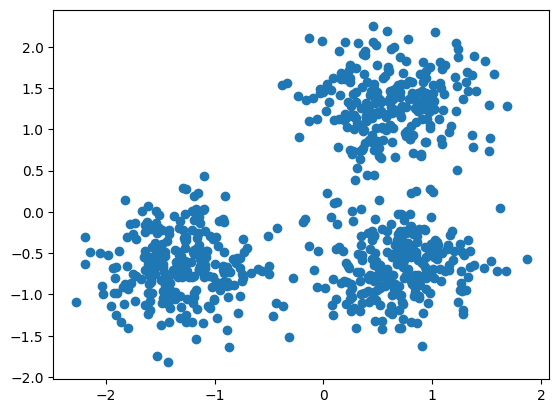

In [4]:
plt.scatter(df['f1'], df['f2'])
plt.show()

There must be 3 species in the dataset as from the plot you can see 3 distinct groups, one in the bottom left, and 2 on the right, one on the top and one on the bottom.

Rough Feature Ranges:

Species 1 has f1 in the range of [-2.5, -0.5] and f2 [-2,0.5]
Species 2 has f1 in the range of [-0.2,1.5] and f2 [-1.7,0]
Species 3 has f1 in the range of [-0.2,1.5] and f2 [0.5,2.2]

In [5]:
X = df.values

In [6]:
X

array([[ 0.49426097,  1.45106697],
       [-1.42808099, -0.83706377],
       [ 0.33855918,  1.03875871],
       ...,
       [-0.05713876, -0.90926105],
       [-1.16939407,  0.03959692],
       [ 0.26322951, -0.92649949]])

K-Means Clustering to find Anomalies

In [7]:
km = KMeans(n_clusters=3, init='random',
            n_init=10, max_iter=300, random_state=0)
y_pred = km.fit_predict(X)
iner = km.inertia_
centers = km.cluster_centers_

In [8]:
np.unique(y_pred)

array([0, 1, 2], dtype=int32)

In [9]:
centers

array([[ 0.62260555,  1.3172598 ],
       [ 0.6954587 , -0.64442334],
       [-1.30266211, -0.65704205]])

In [10]:
dist = lambda a, b : np.sqrt(np.sum((a-b)**2))

In [11]:
X

array([[ 0.49426097,  1.45106697],
       [-1.42808099, -0.83706377],
       [ 0.33855918,  1.03875871],
       ...,
       [-0.05713876, -0.90926105],
       [-1.16939407,  0.03959692],
       [ 0.26322951, -0.92649949]])

In [12]:
distances = np.linalg.norm(X - centers[y_pred], axis=1)

threshold = np.percentile(distances, 95)

anomalies = X[distances > threshold]

anomaly_indices = np.where(distances > threshold)[0]
#print(anomaly_indices)
#print(y_pred)
y_pred_new = y_pred.copy()
y_pred_new[anomaly_indices] = -1
#print(y_pred_new)
# Print or use anomalies as needed
print("Number of anomalies detected:", len(anomalies))
print("Anomalies:\n", anomalies)

Number of anomalies detected: 38
Anomalies:
 [[-1.4302079  -1.82380068]
 [-0.16699918 -0.0916528 ]
 [-0.13447918  2.11039748]
 [ 1.48201718  1.82713556]
 [ 1.22425496  0.50161091]
 [ 1.53624088  0.89460489]
 [ 1.68745105  1.27830756]
 [-1.29275264  0.28788197]
 [-1.53199232 -1.74146844]
 [-0.42227599 -0.19034456]
 [ 1.52307352  0.74115752]
 [ 1.02546663  2.17903747]
 [-0.00943759  2.06614833]
 [-0.46307453 -1.26531795]
 [ 0.09982456  0.10950372]
 [-0.33579552  1.56140541]
 [ 1.62198217  0.05020132]
 [-0.18357785 -0.12543358]
 [-1.82702823  0.13893299]
 [ 0.90491286 -1.62473398]
 [-0.37672226  1.54300065]
 [ 0.45441914  2.24579419]
 [-0.43185167 -1.10093485]
 [-0.3164503  -1.51218921]
 [ 1.38939876  1.88316297]
 [ 0.29375547  0.38990412]
 [ 0.12203814  0.11914361]
 [-2.27447427 -1.08752048]
 [-1.0935262   0.43520463]
 [ 1.5667784   1.67458369]
 [-2.19229513 -0.30228576]
 [ 0.9807011   0.27373202]
 [-0.86338803 -1.63431796]
 [ 1.87043803 -0.56476419]
 [-0.2789764  -0.79571625]
 [-0.37447

In [13]:
show_scatter = lambda X,y: sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

<Axes: >

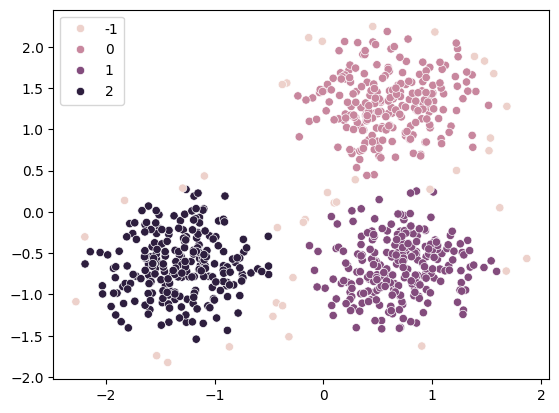

In [14]:
show_scatter(X, y_pred_new)

Anomalies are shown as category -1, these are the data points that are further from the centroids

DBSCAN Clustering to find Anomalies

In [15]:
db = DBSCAN(eps=0.2)

In [16]:
y_pred2 = db.fit_predict(X)

In [17]:
indices = np.where(y_pred2 == -1)[0]

In [18]:
anomalies = X[indices]

In [19]:
print("Number of anomalies detected:", len(anomalies))
print("Anomalies:\n", anomalies)

Number of anomalies detected: 40
Anomalies:
 [[-0.78329914 -1.2248967 ]
 [-1.4302079  -1.82380068]
 [-0.50601383 -0.29571545]
 [-0.16699918 -0.0916528 ]
 [-0.13447918  2.11039748]
 [ 1.48201718  1.82713556]
 [ 1.22425496  0.50161091]
 [ 1.53624088  0.89460489]
 [ 1.68745105  1.27830756]
 [-1.53199232 -1.74146844]
 [-0.42227599 -0.19034456]
 [ 1.52307352  0.74115752]
 [ 1.02546663  2.17903747]
 [-0.00943759  2.06614833]
 [-0.46307453 -1.26531795]
 [ 0.85640775  0.25275335]
 [-0.12897596  1.09716295]
 [-0.904114    0.19181843]
 [ 0.80203144  0.22821584]
 [ 1.62198217  0.05020132]
 [-0.18357785 -0.12543358]
 [-1.82702823  0.13893299]
 [ 0.90491286 -1.62473398]
 [-0.12723135 -0.4090389 ]
 [-0.0811644  -0.70769103]
 [ 1.01170962  0.24102378]
 [-0.43185167 -1.10093485]
 [-0.22115639  0.90920018]
 [-0.3164503  -1.51218921]
 [-1.16838237 -1.5414789 ]
 [-2.27447427 -1.08752048]
 [ 1.37406167  0.78263973]
 [-1.0935262   0.43520463]
 [ 0.9807011   0.27373202]
 [-0.86338803 -1.63431796]
 [ 1.36805

<Axes: >

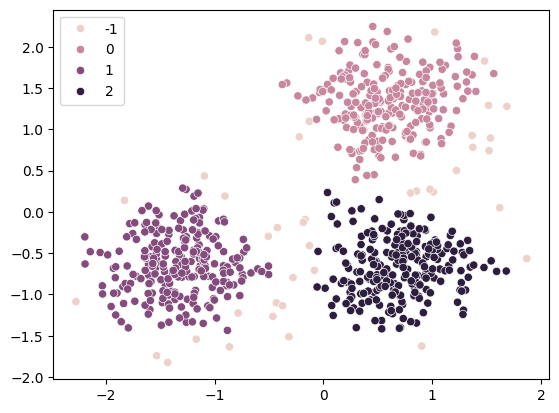

In [20]:
show_scatter(X,y_pred2)

Anomalies are shown as category -1

Removing Anomalies using DBSCAN and training Decision Tree

In [21]:
X_clean = X[y_pred2 != -1]

In [22]:
y_clean = y_pred2[y_pred2 != -1]

<Axes: >

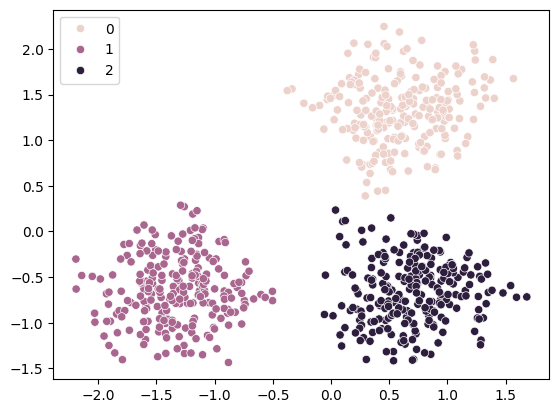

In [23]:
show_scatter(X_clean,y_clean)

In [24]:
from sklearn.tree import DecisionTreeClassifier


In [25]:
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_clean, y_clean)


DecisionTreeClassifier(random_state=0)

In [26]:
plt.rcParams["figure.dpi"] = 72
from IPython.display import display
from sklearn.tree import export_graphviz
from IPython.display import Image
from subprocess import run

import graphviz
print(f'graphviz version= {graphviz.__version__}')

graphviz version= 0.20.3


In [27]:
# export_graphviz will generate a DOT image file in the folder with this notebook
dot_data = export_graphviz(dt,
                           out_file='tree.dot',
                           feature_names=['f1','f2'],
                           class_names=['0','1','2'],
                           filled=True,
                           rounded=True,
                           special_characters=True)

In [28]:
!dot -Tpng tree.dot -o tree.png -Gdpi=72

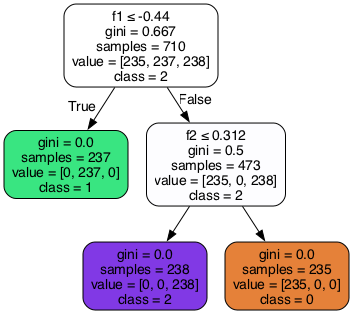

In [29]:
Image(filename = 'tree.png')

The decision tree seems to have split up the classes well with using DBSCAN to remove outliers.

Cleaning Outliers vs Not Cleaning Outliers Performance Analysis

In [30]:
from sklearn.model_selection import cross_val_score, KFold

In [31]:
dt_clf = DecisionTreeClassifier(random_state=0)

In [32]:
kfold = KFold(n_splits=5)

In [33]:
acc = cross_val_score(dt_clf, X_clean, y_clean, cv=kfold, scoring='accuracy')

In [34]:
print(f'Accuracies: {acc}')
print(f'Average: {acc.mean()}')

Accuracies: [1. 1. 1. 1. 1.]
Average: 1.0


In [35]:
acc = cross_val_score(dt_clf, X, y_pred2, cv=kfold, scoring='accuracy')

In [36]:
print(f'Accuracies: {acc}')
print(f'Average: {acc.mean()}')

Accuracies: [0.94       0.96       0.97333333 0.97333333 0.95333333]
Average: 0.96


Removing the outliers and training a decision tree gives 100% accuracy while keeping the outliers and training the decision tree gives an average of 96% accuracy. This means that removing outliers, specifically with DBSCAN, is very helpful and could substantially increase our performance.